In [10]:
import pandas as pd

fruits = pd.read_csv("../Data/fruits.csv")
fruits.head()

,length,weight,name
0,25.4,242.0,apple
1,26.3,290.0,apple
2,26.5,340.0,apple
3,29.0,363.0,apple
4,29.0,430.0,apple


In [11]:
fruits.info()

<class 'pandas.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   length  49 non-null     float64
 1   weight  49 non-null     float64
 2   name    49 non-null     str    
dtypes: float64(2), str(1)
memory usage: 1.3 KB


In [12]:
# 사과 정보 불러오기
apple = fruits[:35]
apple.tail()

,length,weight,name
30,38.5,920.0,apple
31,38.5,955.0,apple
32,39.5,925.0,apple
33,41.0,975.0,apple
34,41.0,950.0,apple


#### apple의 산포도

In [13]:
import matplotlib.pyplot as plt

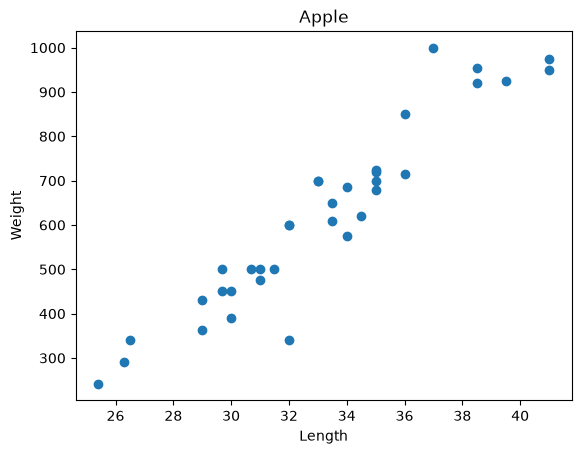

In [14]:
plt.scatter(
	apple.length,
	apple.weight
)

plt.xlabel('Length')
plt.ylabel('Weight')
plt.title("Apple")

plt.show()

In [15]:
# berry 정보 불러오기
berry = fruits[35:]
berry.head()

,length,weight,name
35,9.8,6.7,berry
36,10.5,7.5,berry
37,10.6,7.0,berry
38,11.0,9.7,berry
39,11.2,9.8,berry


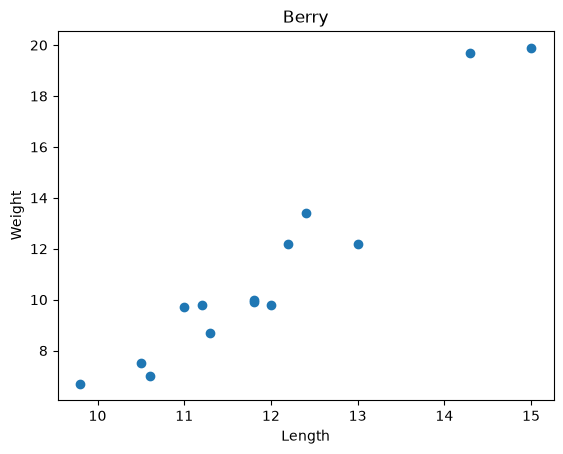

In [16]:
# berry의 산포도
plt.scatter(
	berry.length,
	berry.weight
)

plt.xlabel('Length')
plt.ylabel('Weight')
plt.title("Berry")

plt.show()

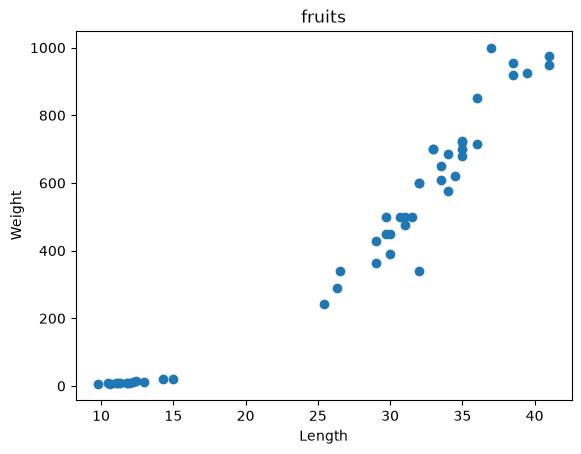

In [17]:
# fruits로 산포도
plt.scatter(
	fruits.length,
	fruits.weight
)

plt.xlabel('Length')
plt.ylabel('Weight')
plt.title("fruits")

plt.show()

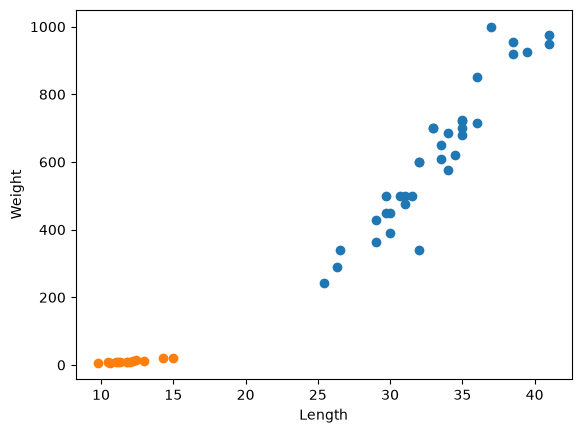

In [18]:
# 2개의 Dataset를 산포도로 한꺼번에 비교하기
plt.scatter(
	apple.length,
	apple.weight
)

plt.scatter(
	berry.length,
	berry.weight
)

plt.xlabel('Length')
plt.ylabel('Weight')

plt.show()

#### 머신러닝을 위한 데이터 준비

- Feature Data와 Target Data 분리

In [19]:
# Feature Data
fruitsData = fruits[['length', 'weight']]
fruitsData.head()

,length,weight
0,25.4,242.0
1,26.3,290.0
2,26.5,340.0
3,29.0,363.0
4,29.0,430.0


In [20]:
fruitsData.info()

<class 'pandas.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   length  49 non-null     float64
 1   weight  49 non-null     float64
dtypes: float64(2)
memory usage: 916.0 bytes


In [21]:
# Target Data
fruitsTarget = fruits['name']
fruitsTarget.head()

0    apple
1    apple
2    apple
3    apple
4    apple
Name: name, dtype: str

In [22]:
fruitsTarget.info()

<class 'pandas.Series'>
RangeIndex: 49 entries, 0 to 48
Series name: name
Non-Null Count  Dtype
--------------  -----
49 non-null     str  
dtypes: str(1)
memory usage: 524.0 bytes


### 최근접이웃(kNN : k Nearest Neighbors) 분류 알고리즘

In [23]:
from sklearn.neighbors import KNeighborsClassifier

In [24]:
# Model 생성
kn = KNeighborsClassifier() # default 5,

In [25]:
# 학습시키기
kn.fit(fruitsData, fruitsTarget)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[object](2,)","['apple','berry']"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [26]:
# 정확도
kn.score(fruitsData,fruitsTarget)

1.0

In [ ]:
# 예측해보기
# 길이가 30cm이고 무게가 600g인것은 무엇인가

